In [28]:
from qiskit import QuantumCircuit
from qiskit import qpy
import numpy as np
from qiskit.quantum_info import Statevector, Operator, partial_trace
from qiskit.circuit.library import UnitaryGate

In [29]:
from scipy.linalg import null_space

def complete_isometry_to_unitary(E, atol=1e-10):
    """
    E: 4x3 isometry, E.conj().T @ E = I_3.
    Returns U_E: 4x4 unitary with first three columns equal to E.
    """
    E = np.asarray(E, dtype=complex)

    if E.shape != (4, 3):
        raise ValueError(f"E must have shape (4,3), got {E.shape}")

    iso_err = np.linalg.norm(E.conj().T @ E - np.eye(3))
    if iso_err > atol:
        raise ValueError(f"E is not an isometry. Error = {iso_err}")

    # Vector orthogonal to all columns of E.
    complement = null_space(E.conj().T)

    if complement.shape != (4, 1):
        raise ValueError(f"Expected one-dimensional complement, got shape {complement.shape}")

    l = complement[:, 0]

    U_E = np.column_stack([E, l])

    unitary_err = np.linalg.norm(U_E.conj().T @ U_E - np.eye(4))
    if unitary_err > atol:
        raise ValueError(f"U_E is not unitary. Error = {unitary_err}")

    return U_E

In [30]:
path = r"C:\Users\szymon\QuditsOnQubits\QuditsOnQubits\basis_direct_encoding_benchmarks\quantum_circuits\ghz3\monomial_full__sup013_P102_ph000"

with open(path + r"/graph_state_direct_basis.qpy", 'rb') as f:
      testqc = qpy.load(f)[0]

with open(path + r"\graph_state_direct_basis_transpiled.qpy", 'rb') as f:
      qcsuptrans = qpy.load(f)[0]

with open(path + r"\F3_W.qpy", 'rb') as f:
      F3sup = qpy.load(f)[0]
      
Esup = np.load(path + r"\E.npy")

In [31]:
Operator(Esup).draw('latex')

<IPython.core.display.Latex object>

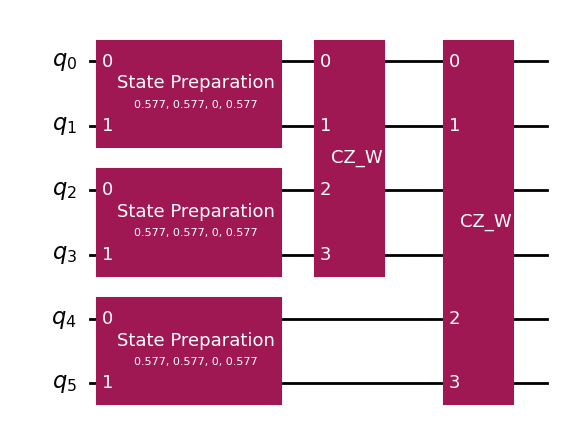

In [32]:
testqc.draw("mpl")

In [33]:
Statevector(testqc).draw('latex')

<IPython.core.display.Latex object>

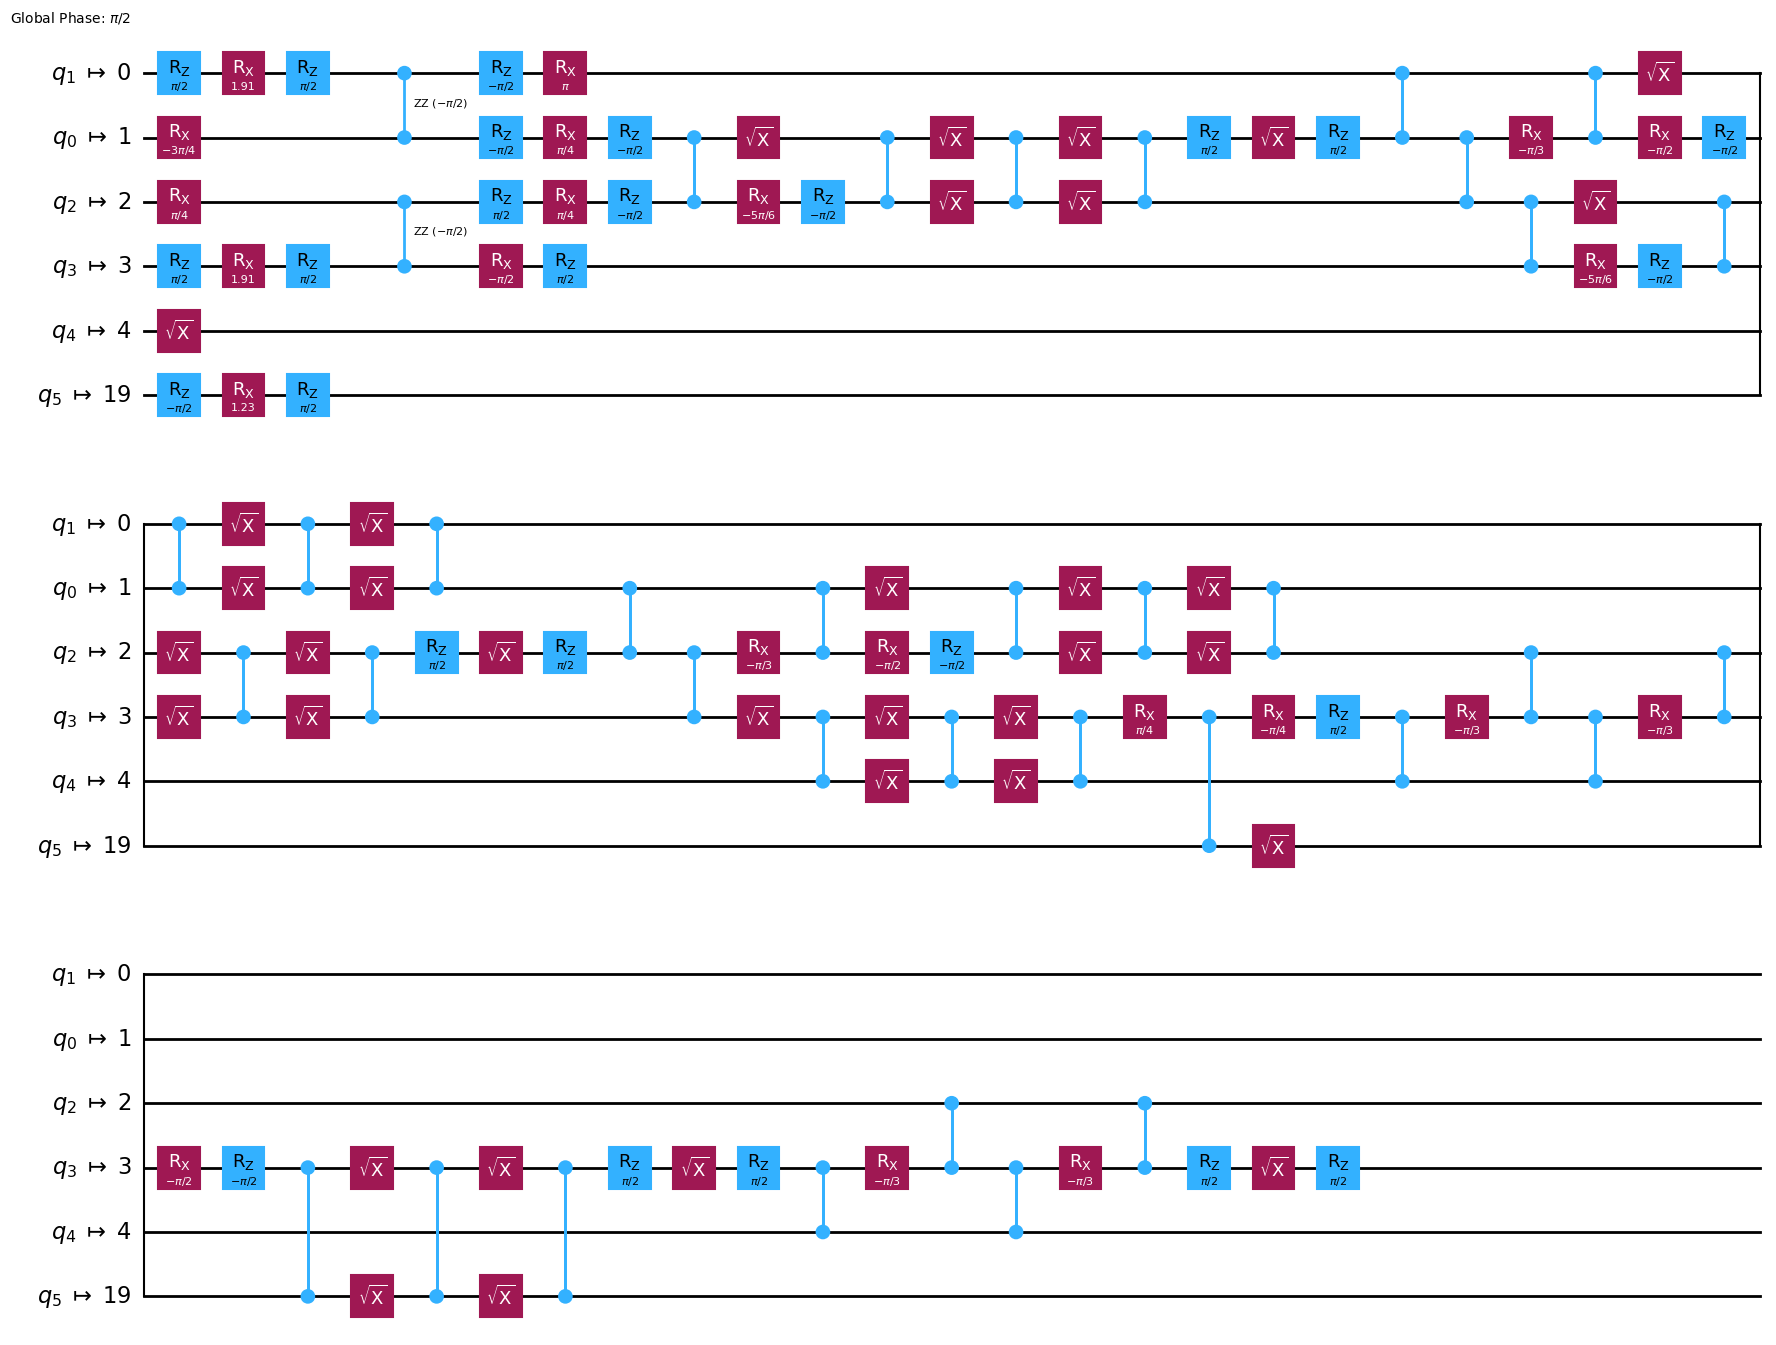

In [34]:
qcsuptrans.draw('mpl')

In [35]:
F3supdag = UnitaryGate(Operator(F3sup).data.T.conjugate())

In [36]:
Uesup = complete_isometry_to_unitary(Esup)

In [37]:
Uesupdag = Uesup.conjugate().T
Uedaggate = UnitaryGate(Uesupdag)

In [38]:
basechangeqc = testqc.copy()

basechangeqc.append(F3supdag, [2, 3])
basechangeqc.append(F3supdag, [4, 5])
# basechangeqc.append(Uedaggate, [0, 1])
# basechangeqc.append(Uedaggate, [2, 3])

Statevector(basechangeqc).draw('latex')

<IPython.core.display.Latex object>